# Projet La Capsule - Diabète

Ce notebook présente notre exploration des données collectées entre 1999 et 2008 aux Etats Unis sur le traitement du diabète à l'hopital avec pour but, *prior* Machine Learning, de nous aiguiller sur une première réponse à la problématique suivante : **quels les facteurs actionnables pouvant limiter les ré-admission de patients atteints du diabètes sous 30 jours ?**

Pour ce faire, nous utiliserons les données transformées par dbt, mises à disposition sur BigQuery.

*Note importante* : la publication accompagnant les données ayant déjà mis en évidence la forte influence du test HbA1c (si le test est réalisé, le patient a moins de chance d'être réadmis) nous avons décidé de ne pas inclure cette feature dans notre modèle. Une raison complémentaire à cette exclusion est le fait que ce test soit très peu fréquemment réalisé sur la période étudié (moins de 17% des hospitalisations).



[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/valrqr/data-portfolio/blob/main/Data%20-%20Portfolio%20formation/Projet%20Fin%20de%20Formation/Projet_Diabete_exploration_des_donnees.ipynb)

In [ ]:
import pandas as pd
import numpy as np

import plotly.express as px
import matplotlib.pyplot as plt



## Création du DataFrame

Pour créer le DataFrame, nous devons :
- Télécharger les différentes tables du dataset "dbt_shared" du projet "projetdiabeteus" sur BigQuery
- Fusionner la table de faits (hospitalisations) avec ses tables de dimensions
- Sauvegarder le DataFrame complet ainsi créé

Ces étapes sont réalisés par le script `creation_dataset.py`

## Exploration des données

In [ ]:
# Lecture des données
df = pd.read_csv(
    "/content/diabetes.csv",
    keep_default_na = False) # On ne veut pas interpréter les valeurs NULL comme NA

Vérifions la taille des données :

In [ ]:
df.shape

(101766, 34)

Vérifions les types des colonnes :

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 34 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   hospitalisation_id            101766 non-null  int64 
 1   patient_id                    101766 non-null  int64 
 2   type_admission_id             101766 non-null  int64 
 3   sortie_id                     101766 non-null  int64 
 4   source_admission_id           101766 non-null  int64 
 5   specialite_id                 101766 non-null  int64 
 6   tranche_age                   101766 non-null  object
 7   duree                         101766 non-null  int64 
 8   n_test_lab                    101766 non-null  int64 
 9   n_procedure                   101766 non-null  int64 
 10  n_medicament                  101766 non-null  int64 
 11  n_visite_externe              101766 non-null  int64 
 12  n_visite_urgence              101766 non-null  int64 
 13 

Conforme et pas de valeur manquante (remplacées par des '?')

In [ ]:
# identification des possibles doublons -> observation : pas de doublons
print("Lignes dupliquées (toutes colonnes) :", df.duplicated().sum())
print("Hospitalisations dupliquées (hospitalisation_id) :", df.duplicated(subset=["hospitalisation_id"]).sum())

Lignes dupliquées (toutes colonnes) : 0
Hospitalisations dupliquées (hospitalisation_id) : 0


Pas de ligne ou d'hospitalisation dupliquée

---



#Identification de notre *Target*

Notre target, variable à prédire, est ``readmis`` (1 si patient réadmis à l'hôpital moins de 30 jours après la primo-hospitalisation, 0 sinon)

In [ ]:
col_target = "readmis"

readmis
0    88.84
1    11.16
Name: proportion, dtype: float64


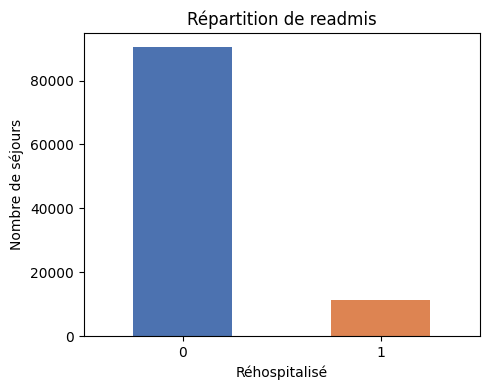

In [ ]:
readmis_counts = df[col_target].value_counts(normalize=True) * 100 # pourcentage de réadmis vs réadmis +30jours ou non réadmis
print(readmis_counts.round(2))
#graph d'illustration :
fig, ax = plt.subplots(figsize=(5, 4))
df[col_target].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Répartition de readmis")
ax.set_xlabel("Réhospitalisé")
ax.set_ylabel("Nombre de séjours")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**11.16%** des hospitalisations sont des réadmissions.

Ce déséquilibre pose un défi avec la future modélisation:
- Un modèle naïf qui prédirait « pas de réadmission » pour chaque hospitalisation atteindrait 89% de précision
-> C'est pourquoi nous privilégirons le recall et la courbe ROC plutôt que la simple précision globale. Le rappel mesure le pourcentage de réadmissions effectivement détectées.

### Filtres pré-traitement

Pour des raisons évidentes, nous ne souhaitons pas conserver les hospitalisations ayant entrainé la mort ou une sortie vers un hospice.

In [ ]:
print(df.shape)
df = df[~df["categorie_sortie"].isin(["Expired/Deceased", "Hospice"])]
print(df.shape)

(101766, 34)
(99343, 34)


Ceci filtre 2 423 (2.3%) des hospitalisations.

### Features numériques

Explorons les features numériques (toutes discrètes).

In [ ]:
cols_num = [
    "duree",
    "n_test_lab",
    "n_procedure",
    "n_medicament",
    "n_visite_externe",
    "n_visite_urgence",
    "n_visite_hopital",
    "n_diag",
    "n_changement_posologie",
    "readmis"
]

array([[<Axes: title={'center': 'duree'}>,
        <Axes: title={'center': 'n_test_lab'}>,
        <Axes: title={'center': 'n_procedure'}>,
        <Axes: title={'center': 'n_medicament'}>],
       [<Axes: title={'center': 'n_visite_externe'}>,
        <Axes: title={'center': 'n_visite_urgence'}>,
        <Axes: title={'center': 'n_visite_hopital'}>,
        <Axes: title={'center': 'n_diag'}>],
       [<Axes: title={'center': 'n_changement_posologie'}>,
        <Axes: title={'center': 'readmis'}>, <Axes: >, <Axes: >]],
      dtype=object)

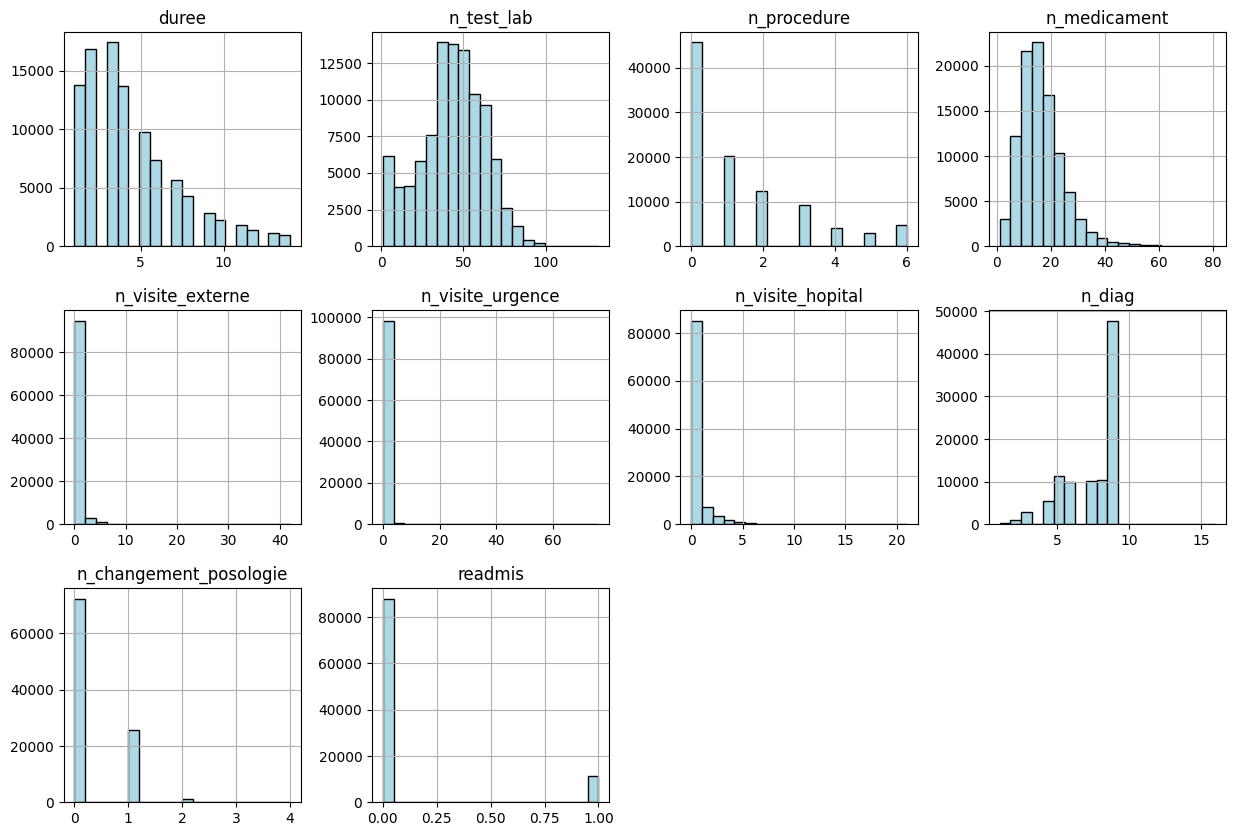

In [ ]:
df[cols_num].hist(bins=20, figsize=(15, 10), layout=(3, 4), color="lightblue", edgecolor="black")

Les valeurs minimales sont toutes 0 et les valeurs maximales sont variables mais restent relativement proches (max: 100).

Observations principales :
- ``n_visite_externe``, ``n_visite_urgence`` et ``n_visite_hopital`` ont toutes trois des heavy tail coté droit, avec presque toutes les valeurs concentrées vers 0.
- ``n_diag`` a un pic à 9, et presque aucune valeur n'apparait ensuite, ce qui parait étrange. Il est possible qu'il n'était pas possible d'entrer plus de 9 diagnostiques dans la BDD ? En tout cas, cela ressemble a un artefact humain... Dommage, cette colonne aurait pu être très utile !

Explorons comment ces variables sont liées à notre target à l'aide d'heatmaps :

In [ ]:
def ci_proportion(group):
    """
    Calcul l'inetrvalle de confiance à 95% pour une proportion (moyenne d'une variable binaire) dans un groupe.
    """
    n = len(group)
    if n <= 1:
        return 0, 1, 0
    p = group.mean()
    se = np.sqrt(p * (1 - p) / n)
    return p - 1.96*se, p + 1.96*se, se # 1.96 est le quantile de la loi normale pour un intervalle de confiance à 95%

def plot_crosstab(df, col_feature, col_target=col_target, y=["Non-Réadmis", "Réadmis", "Total"]):
    mean_target = df[col_target].mean()
    group = df.groupby(col_feature)[col_target]
    proportion_of_1 = group.mean()
    errors = group.apply(ci_proportion)
    if df[col_feature].dtype in ["str", "object"]:
        proportion_of_1 = proportion_of_1.sort_values(ascending=False)
        p = proportion_of_1.plot.bar(figsize=(12, 5), color='lightblue', edgecolor='black', yerr=errors.apply(lambda x: x[2]))
    else:
        p = proportion_of_1.plot(figsize=(12, 5))
        p.fill_between(proportion_of_1.index, errors.apply(lambda x: x[0]), errors.apply(lambda x: x[1]),
                alpha=0.2, color='red', label='Interval de confiance 95%')
    p.axhline(mean_target, color='red', linestyle='--', linewidth=2, label='Moyenne')
    plt.legend()
    plt.show()
    px.imshow(
    round(
        pd.crosstab(
            df[col_target],
            df[col_feature],
            margins=True,
            normalize="index")
        * 100,
        2).reset_index(drop=True),
    color_continuous_scale='RdBu_r',
    text_auto=True,
    aspect="auto",
    y=y,
    zmin=0).show()

          readmis     duree
readmis  1.000000  0.046886
duree    0.046886  1.000000


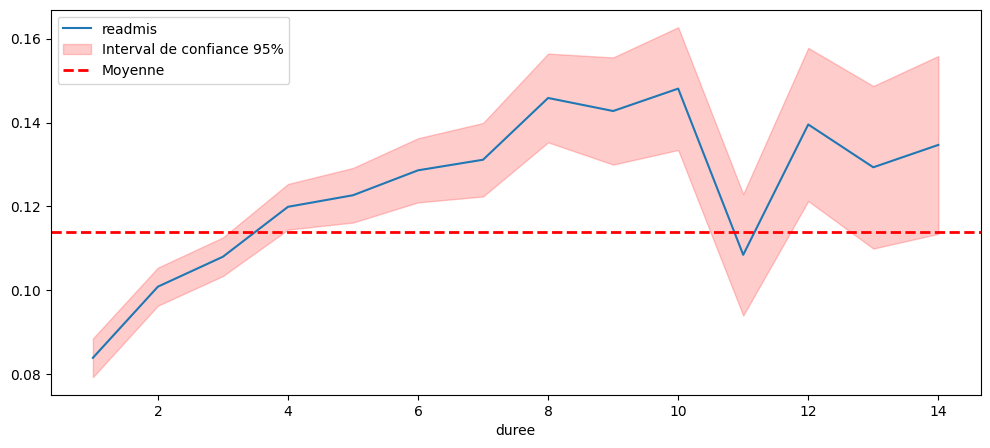

             readmis  n_test_lab
readmis     1.000000    0.024044
n_test_lab  0.024044    1.000000


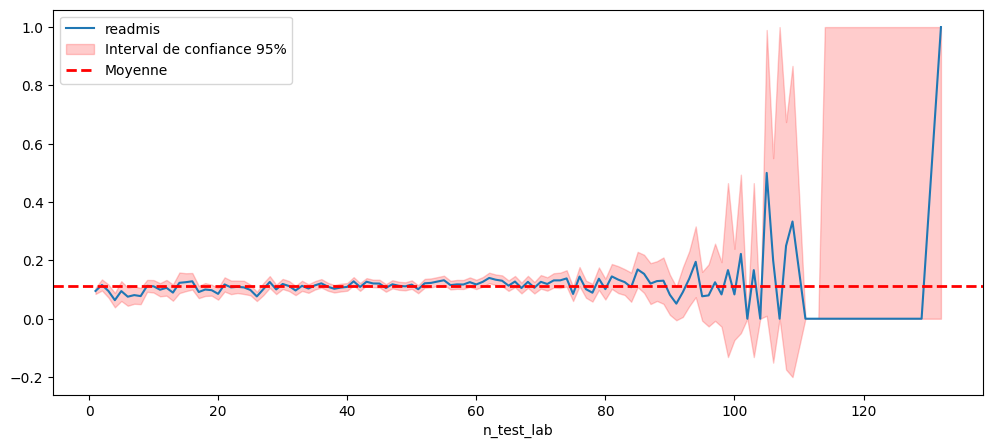

              readmis  n_procedure
readmis      1.000000    -0.010841
n_procedure -0.010841     1.000000


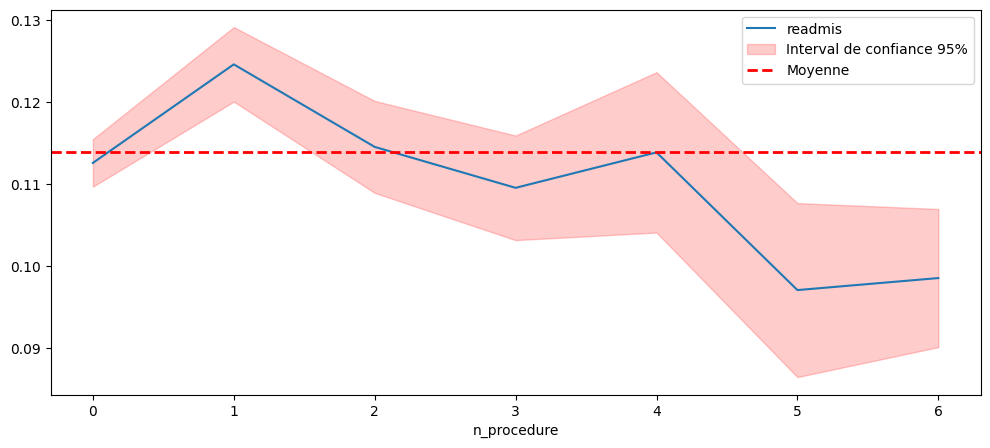

               readmis  n_medicament
readmis       1.000000      0.041179
n_medicament  0.041179      1.000000


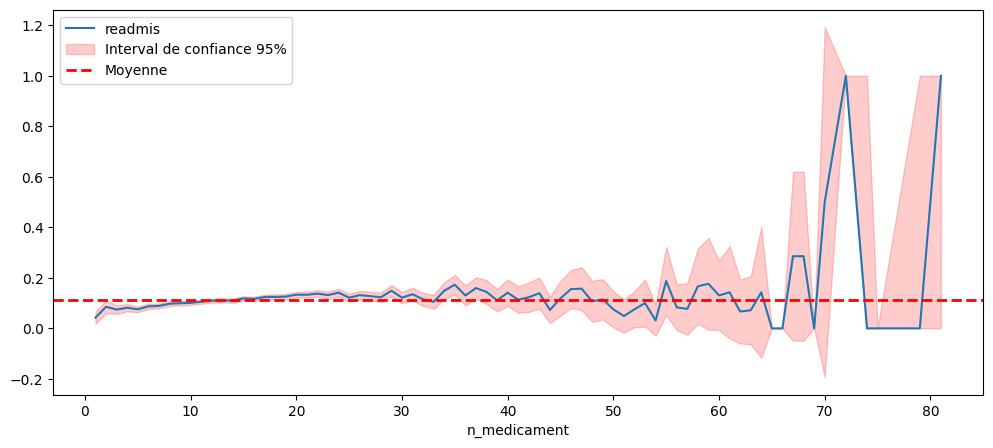

                   readmis  n_visite_externe
readmis           1.000000          0.019169
n_visite_externe  0.019169          1.000000


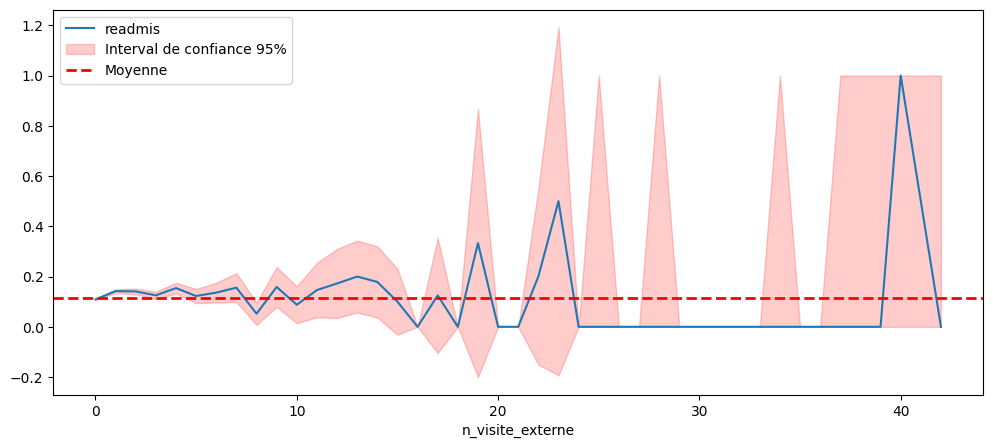

                   readmis  n_visite_urgence
readmis           1.000000          0.060885
n_visite_urgence  0.060885          1.000000


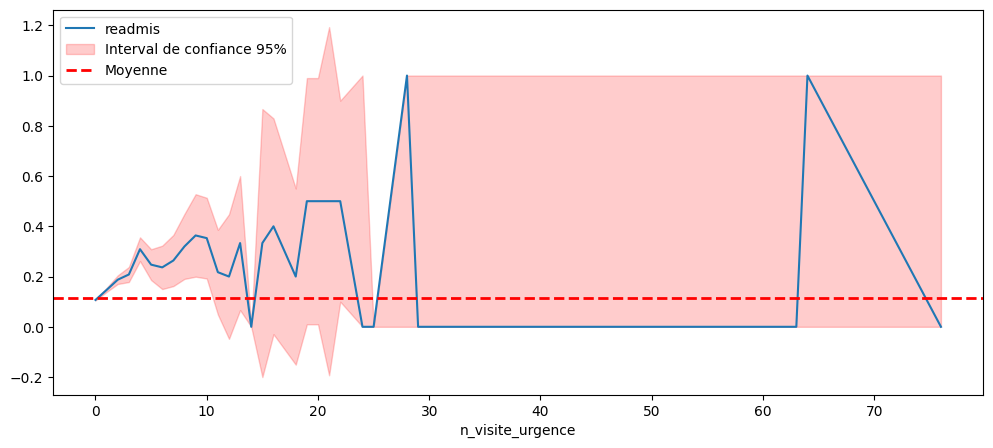

                   readmis  n_visite_hopital
readmis           1.000000          0.168326
n_visite_hopital  0.168326          1.000000


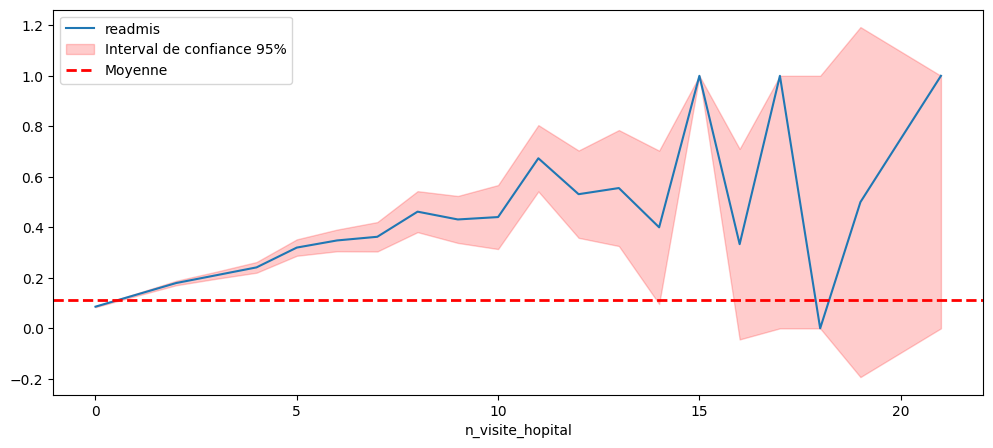

         readmis   n_diag
readmis  1.00000  0.05358
n_diag   0.05358  1.00000


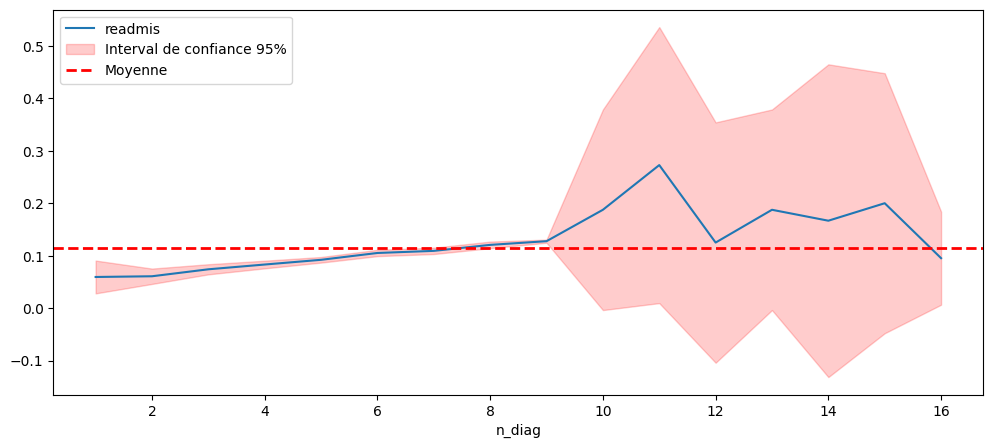

                        readmis  n_changement_posologie
readmis                 1.00000                 0.03564
n_changement_posologie  0.03564                 1.00000


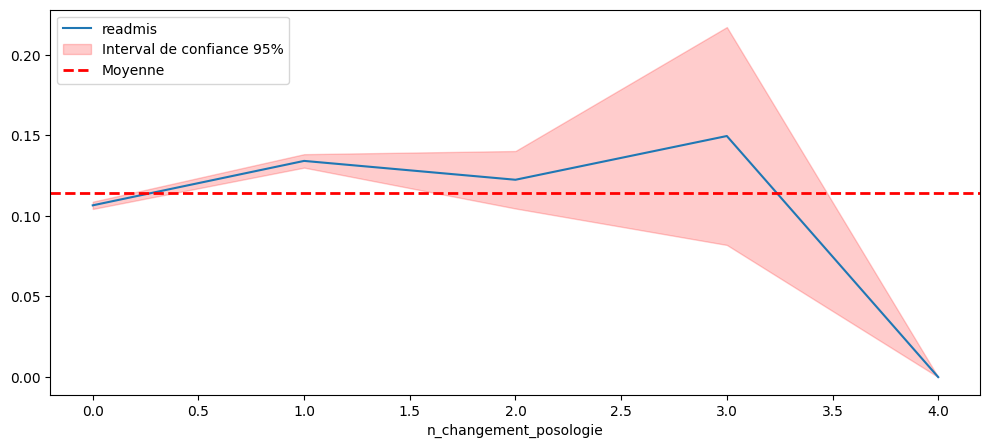

In [ ]:
for col_feature in cols_num[:-1]:
    print(df[[col_target, col_feature]].corr())
    plot_crosstab(df, col_feature)

Nous confirmons les problèmes observés précédement avec les colonnes ``n_diag``, ``n_visite_externe``, ``n_visite_urgence`` et ``n_visite_hopital``.
- Solution proposée pour ``n_visite_externe``, ``n_visite_urgence`` et ``n_visite_hopital`` :
  - Définir une nouvelle colonne ``score_visite = n_visite_externe > 0 + n_visite_urgence > 0 + n_visite_hopital``
  - Max : 10 (score sur 10)
- Solution proposée pour ``n_test_lab``
  - Max : 100
- Solution proposée pour ``n_medicament``
  - Max : 50
- Solution proposée pour ``n_diag`` :
  - Passer les hospitalisations avec plus de 9 diagnostiques à 9

Nouvelles observations :

- Un changement de posologie semble faiblement associé avec une réadmission
- Le nombre de visite médicale dans l'année précédent l'hospitalisation semble être notre meilleur prédicateur de la réadmission
- D'autres variables faiblement corrélées avec la réadmission : durée de l'hospitalisation, nombre de diagnostic, nombre de médicament, nombre de test en labo

#### Tranformation des features numériques

In [ ]:
max_test_lab = 100
max_medicament = 50

In [ ]:
max_score_visite = 10
col_n_visite_medicale = "score_visite"
cols_num_new = ["score_visite"]
df["score_visite"] = (df["n_visite_externe"] > 0).astype(int) + (df["n_visite_urgence"] > 0).astype(int) + df["n_visite_hopital"]
df["score_visite"] = np.where(df["score_visite"] > max_score_visite, max_score_visite, df[col_n_visite_medicale])
df[col_n_visite_medicale].describe()

,score_visite
count,99343.000000
mean,0.901463
std,1.440702
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,10.000000


In [ ]:
df["n_test_lab"] = np.where(df["n_test_lab"] > max_test_lab, max_test_lab, df["n_test_lab"])
df["n_medicament"] = np.where(df["n_medicament"] > max_medicament, max_medicament, df["n_medicament"])
cols_num_new.extend(["n_test_lab", "n_medicament"])

In [ ]:
df["n_diag_max_8"] = np.where(df["n_diag"] > 9, 9, df["n_diag"])
cols_num_new.append("n_diag_max_8")

Vérification des nouvelles distributions :

array([[<Axes: title={'center': 'score_visite'}>,
        <Axes: title={'center': 'n_test_lab'}>,
        <Axes: title={'center': 'n_medicament'}>,
        <Axes: title={'center': 'n_diag_max_8'}>],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object)

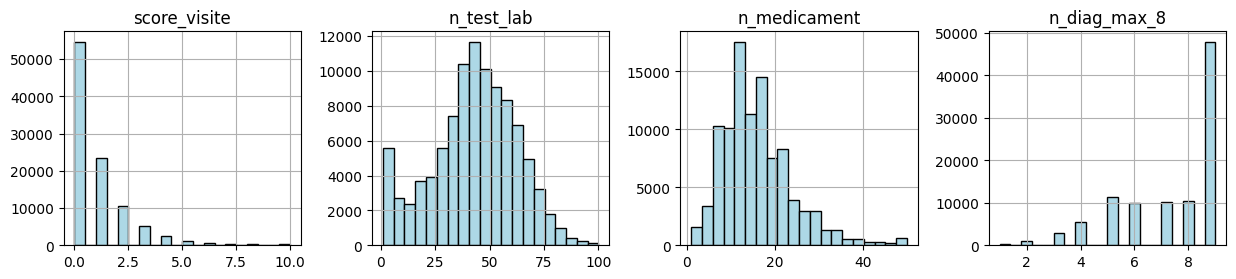

In [ ]:
df[cols_num_new].hist(bins=20, figsize=(15, 10), layout=(3, 4), color="lightblue", edgecolor="black")

               readmis  score_visite
readmis       1.000000      0.164095
score_visite  0.164095      1.000000


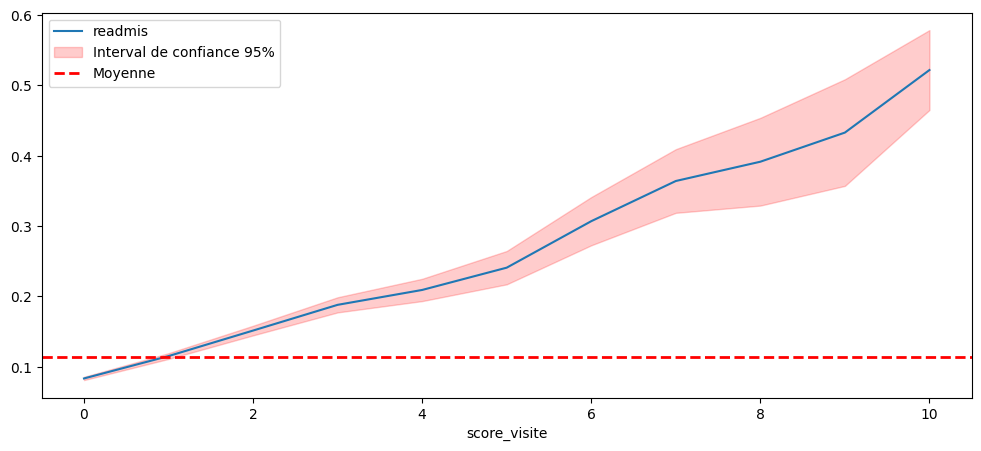

             readmis  n_test_lab
readmis     1.000000    0.024018
n_test_lab  0.024018    1.000000


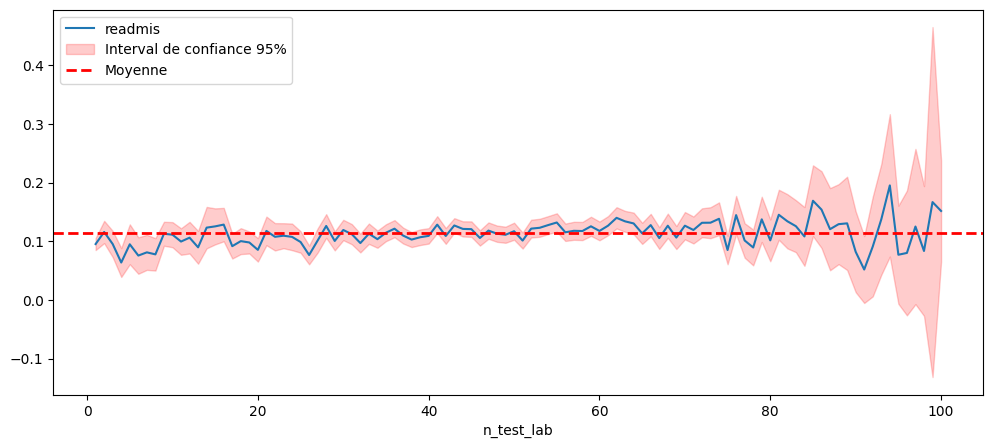

               readmis  n_medicament
readmis       1.000000      0.041585
n_medicament  0.041585      1.000000


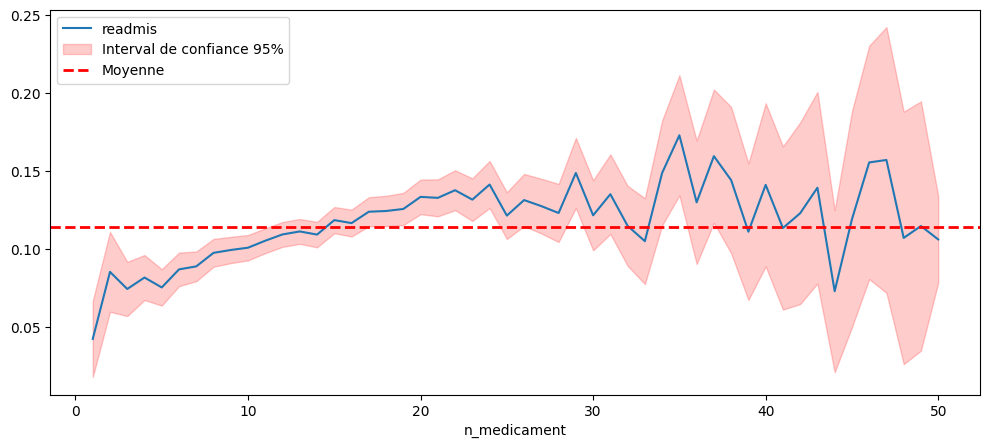

               readmis  n_diag_max_8
readmis       1.000000      0.053732
n_diag_max_8  0.053732      1.000000


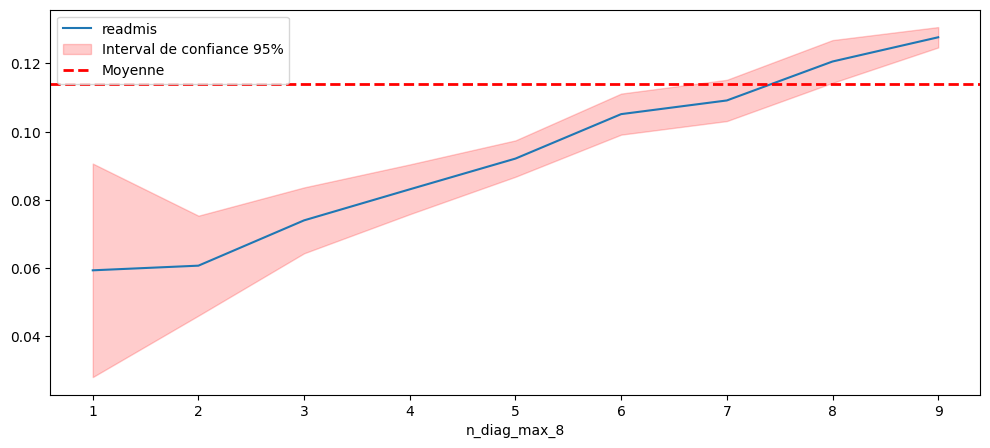

In [ ]:
for col_feature in cols_num_new:
    print(df[[col_target, col_feature]].corr())
    plot_crosstab(df, col_feature)

#### Corrélations entre features numériques

In [ ]:
for i, c1 in enumerate(cols_num[:-2]):
    for j, c2 in enumerate(cols_num[i+1:-1]):
        cor = round(df[[c1, c2]].corr().iloc[0, 1], 2)
        if cor > 0.2:
            print(f"Correlation entre {c1} et {c2}: {cor}")

Correlation entre duree et n_test_lab: 0.32
Correlation entre duree et n_medicament: 0.47
Correlation entre duree et n_diag: 0.22
Correlation entre n_test_lab et n_medicament: 0.27
Correlation entre n_procedure et n_medicament: 0.38
Correlation entre n_medicament et n_diag: 0.27
Correlation entre n_medicament et n_changement_posologie: 0.23
Correlation entre n_visite_urgence et n_visite_hopital: 0.27


*Quelques* corrélations élevées mais rien d'alarmant.

### Features non-numériques

Explorons les features non-numériques.

In [ ]:
df["tranche_age"] = pd.Categorical(df["tranche_age"], categories=["[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)", "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"], ordered=True)

In [ ]:
cols_cat = [
    'tranche_age',
    'insulin',
    'ethnie',
    'genre',
    'categorie_sortie',
    'categorie_source_admission',
    'categorie_specialite',
    'categorie_type_admission',
    'categorie_1', 'categorie_2', 'categorie_3',
]

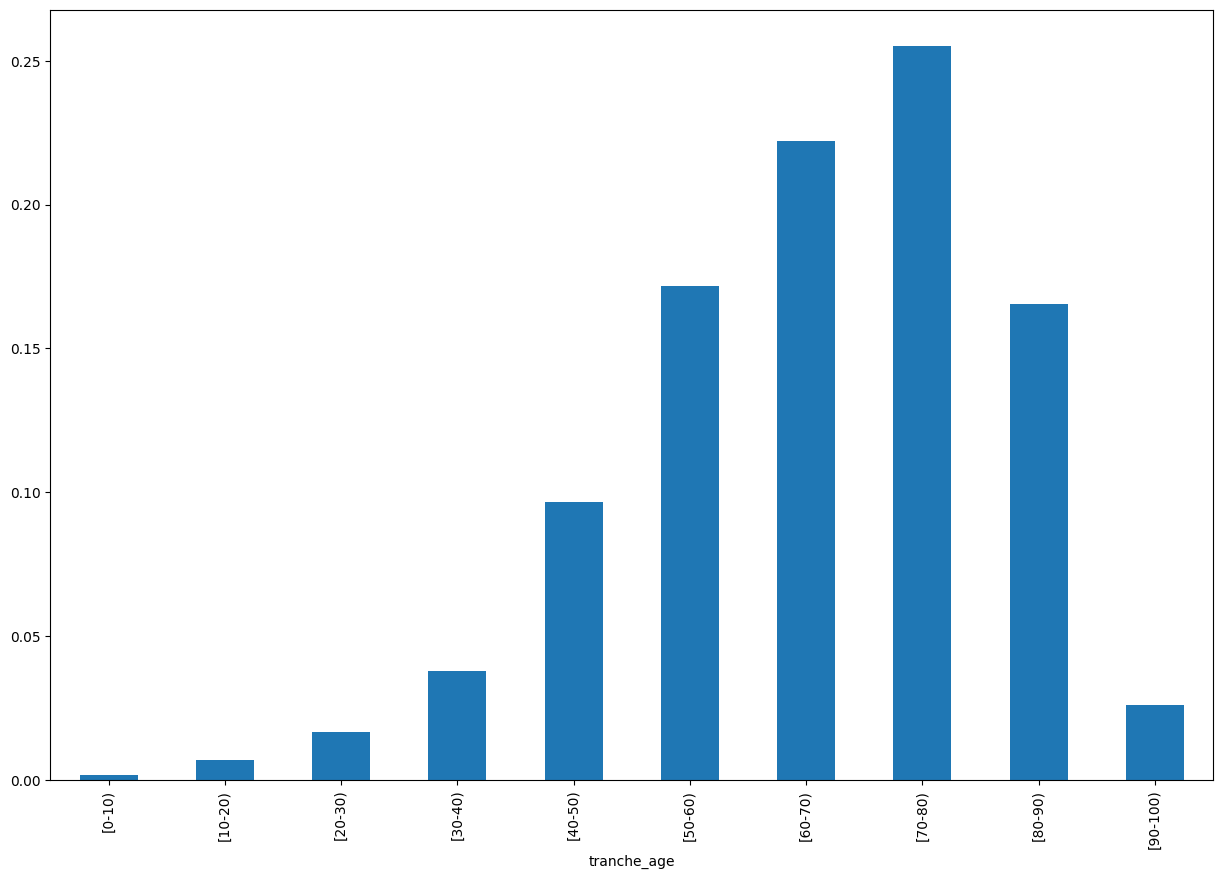

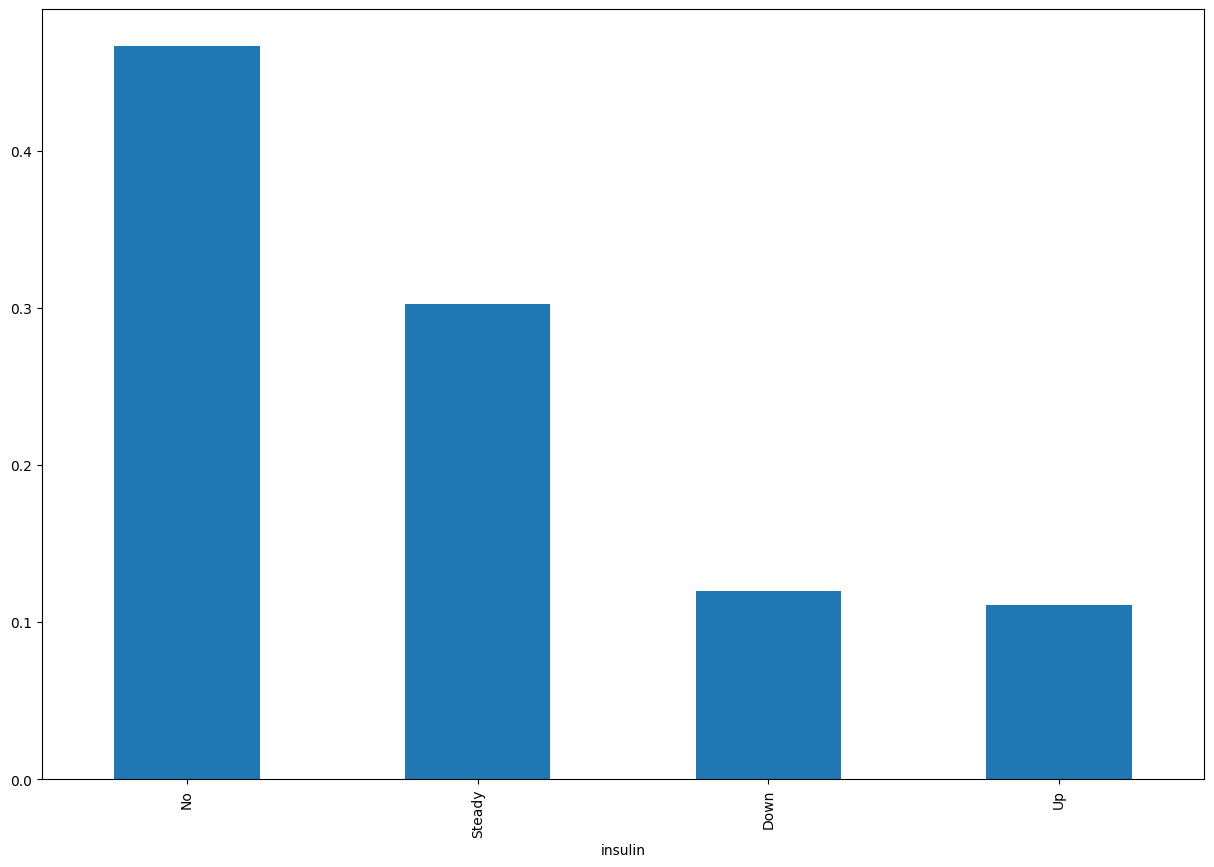

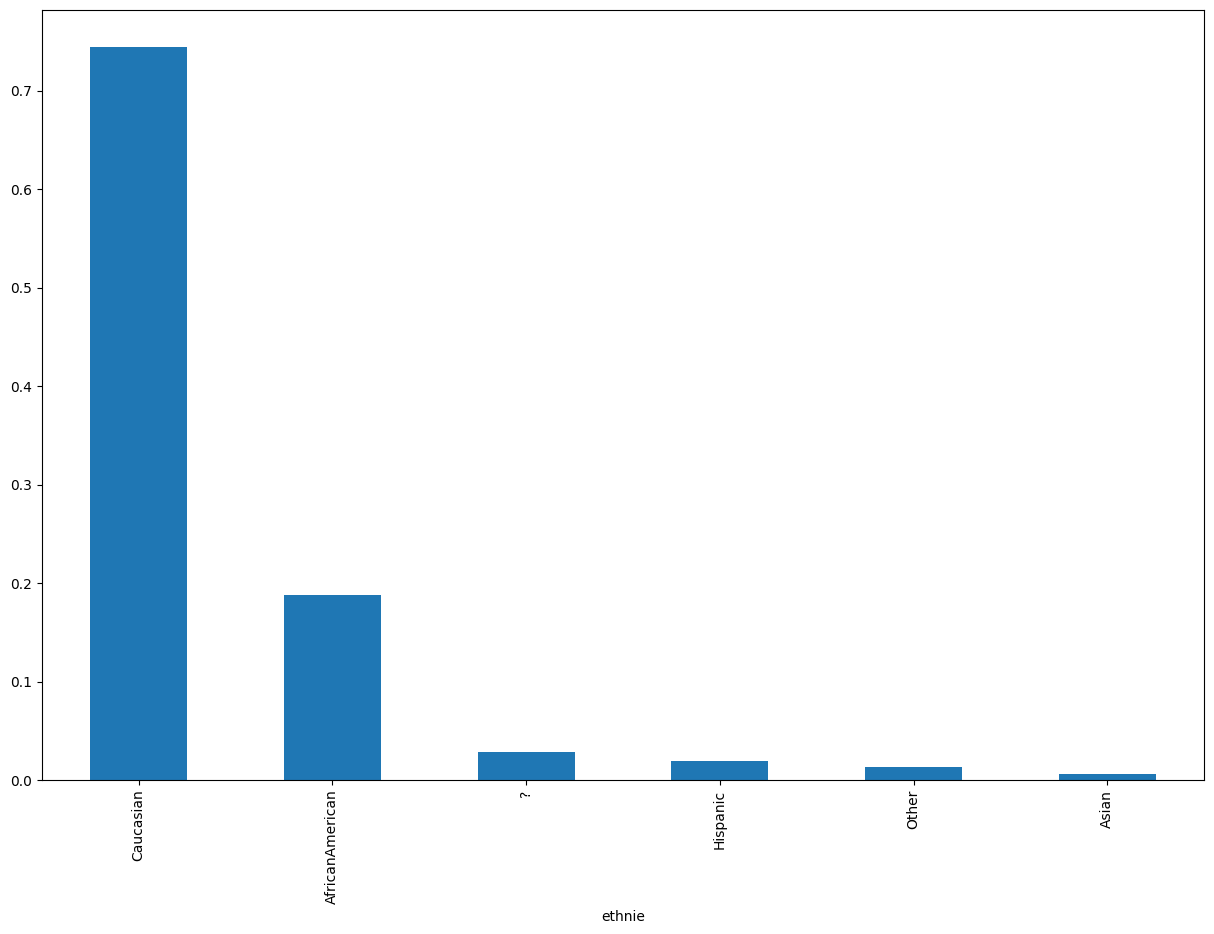

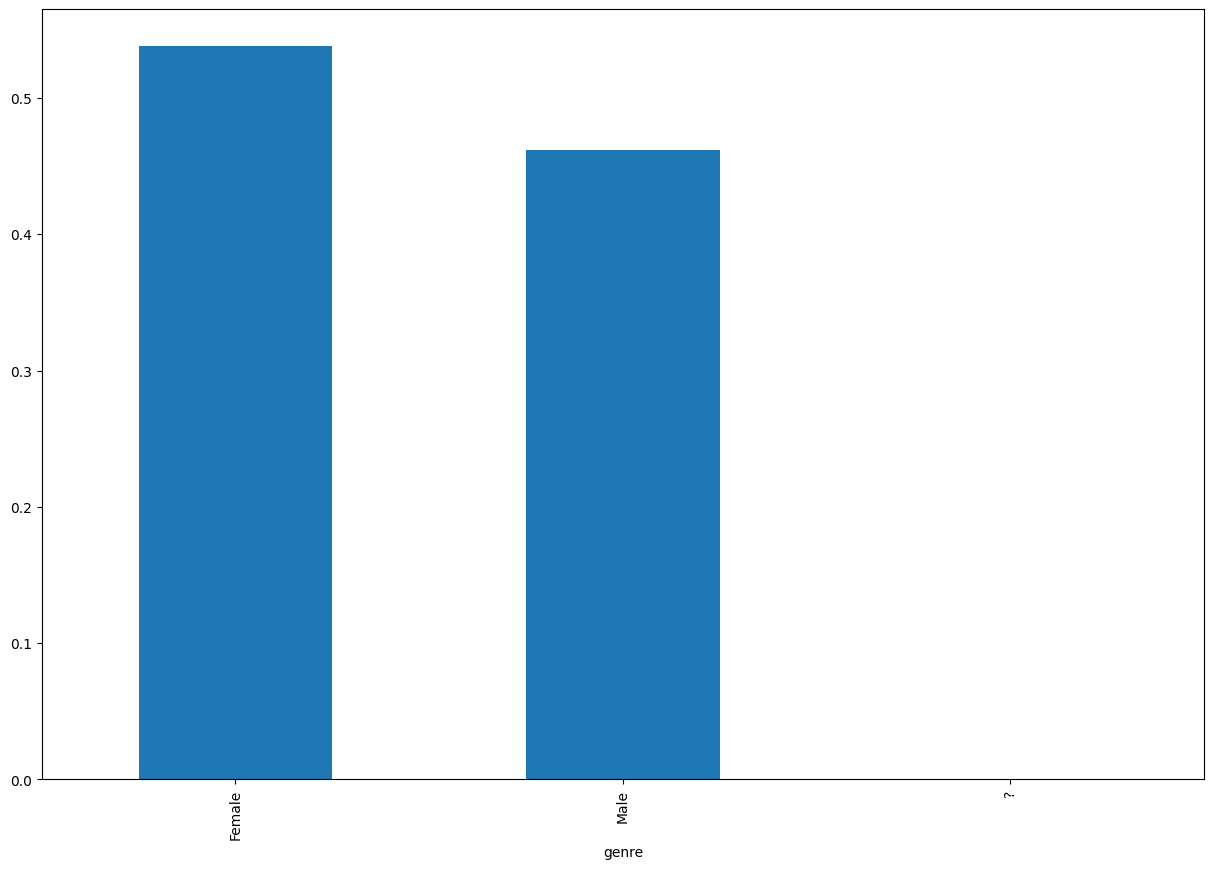

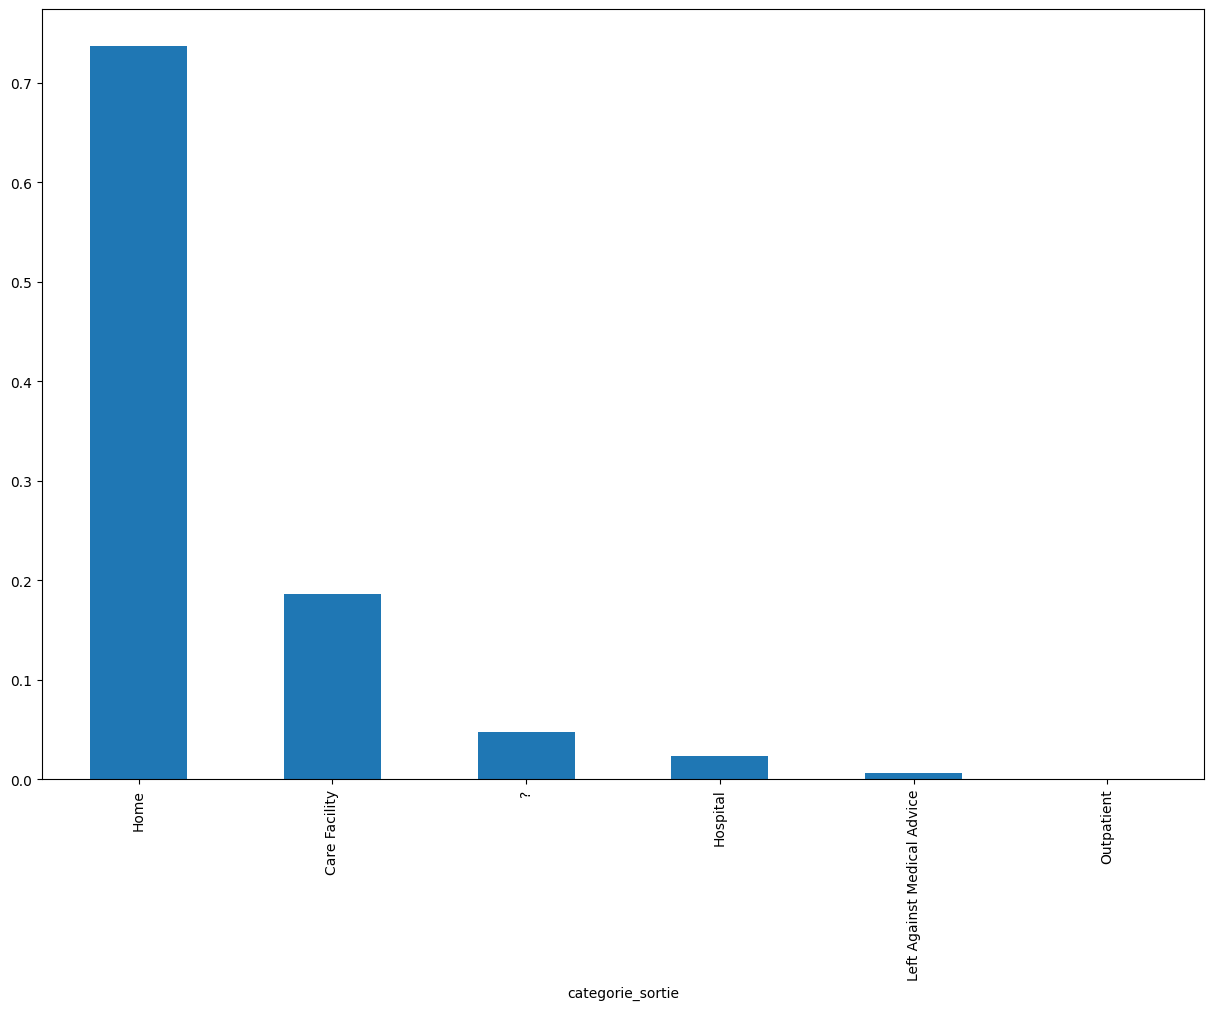

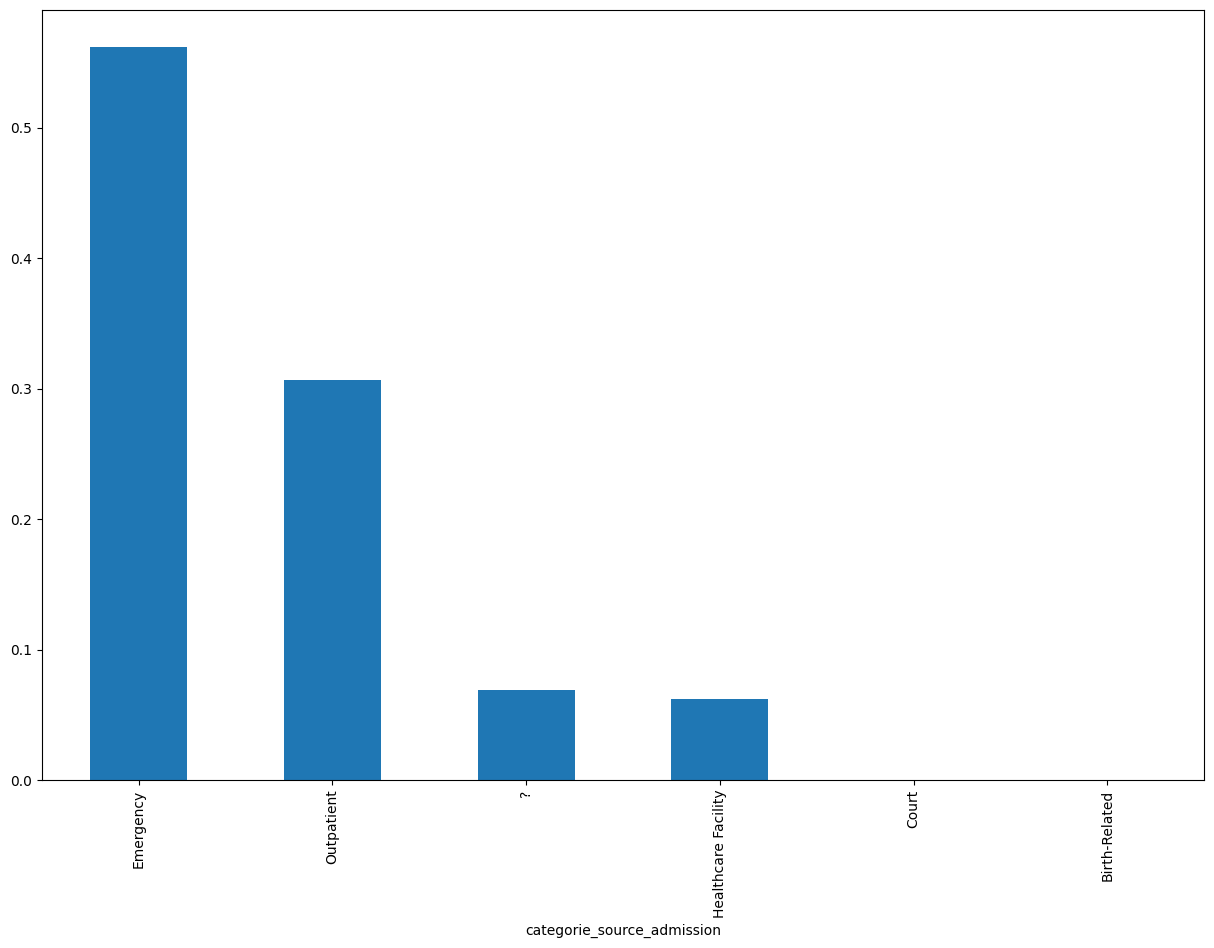

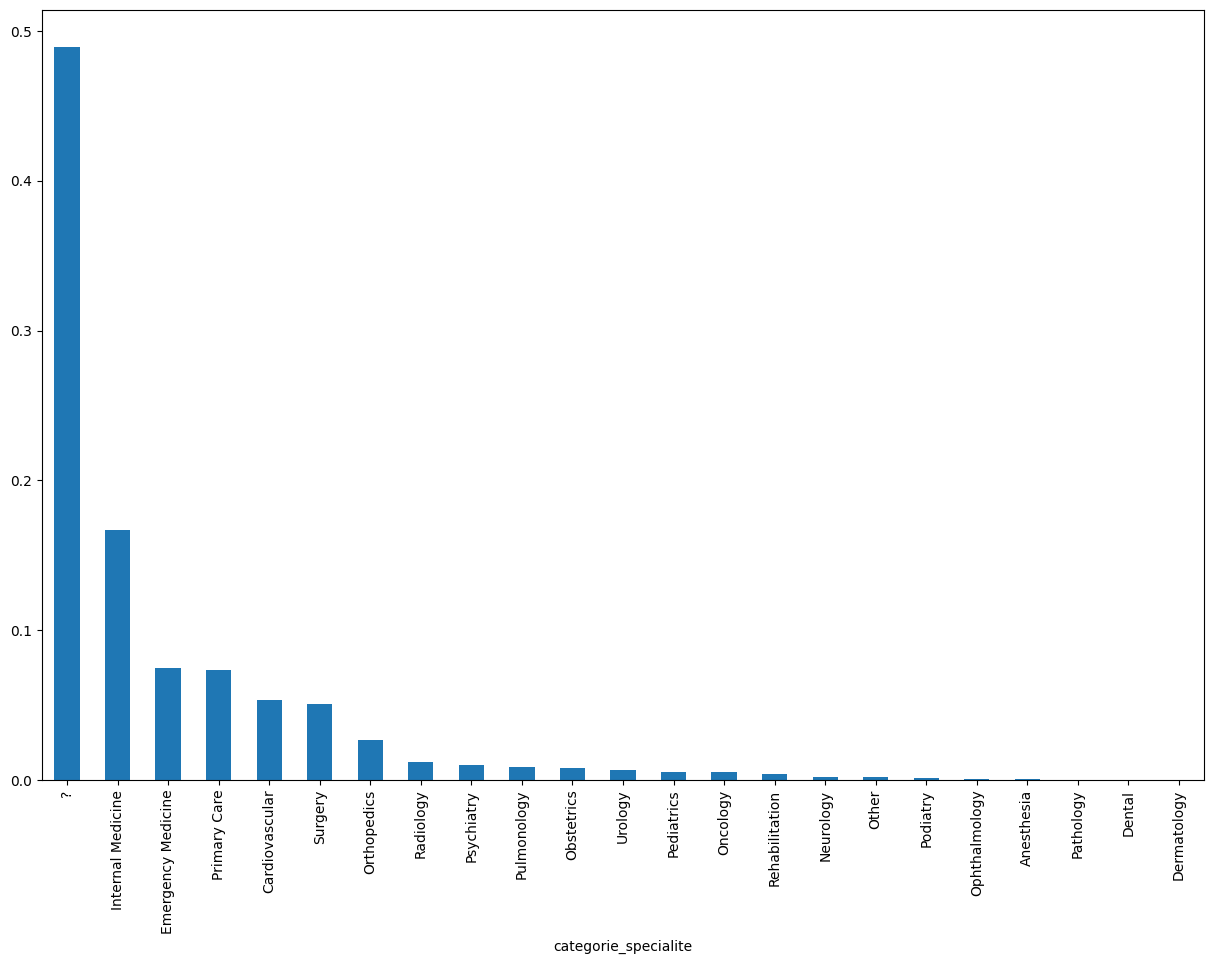

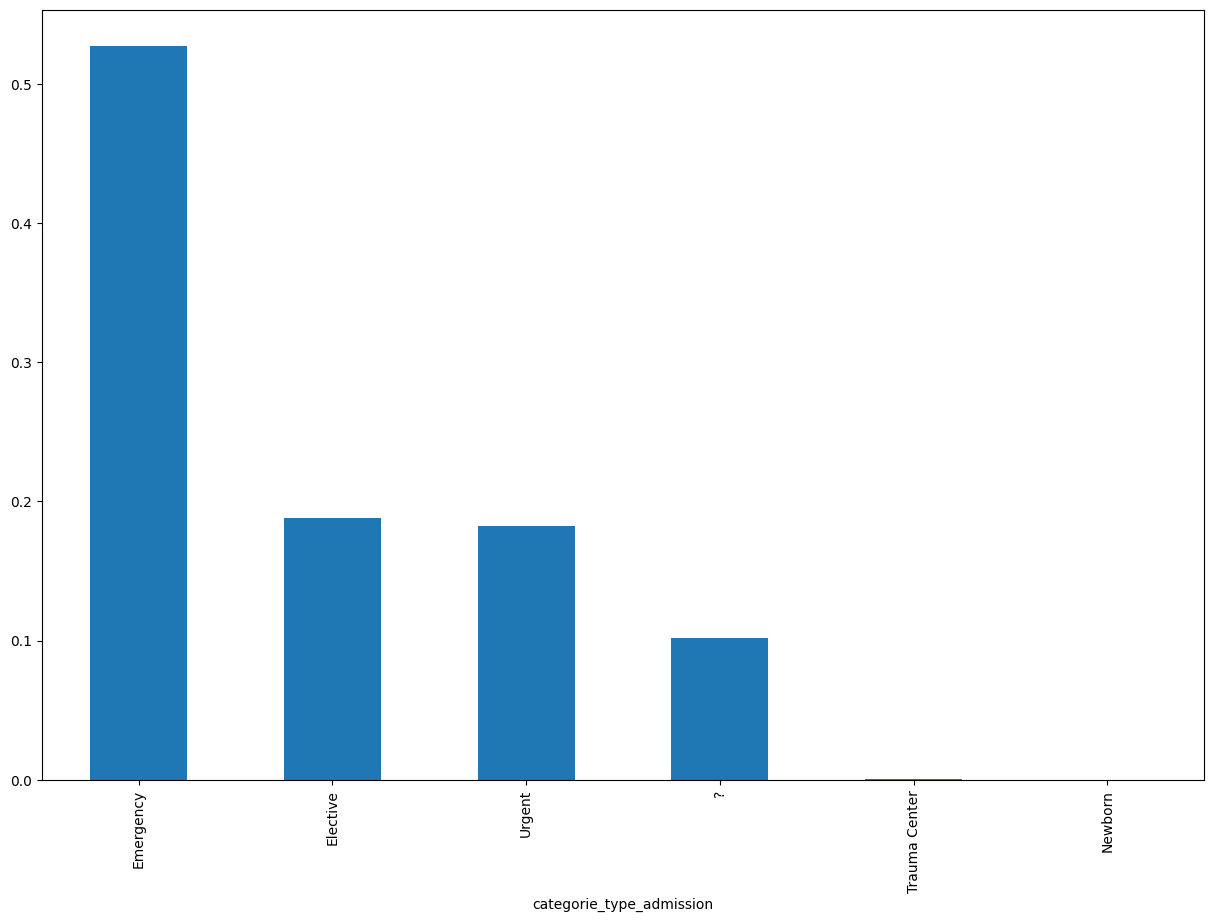

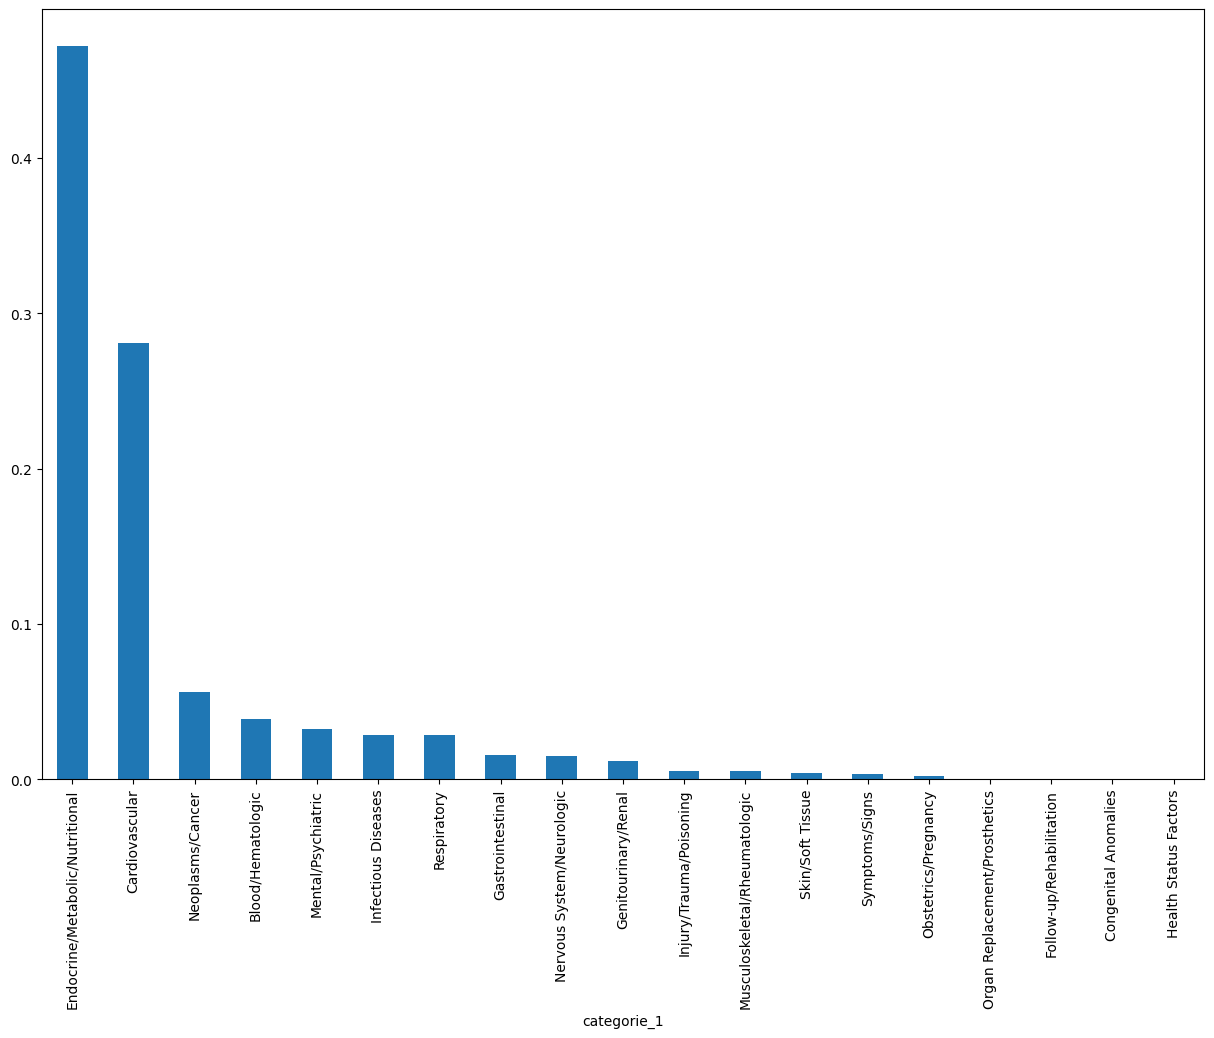

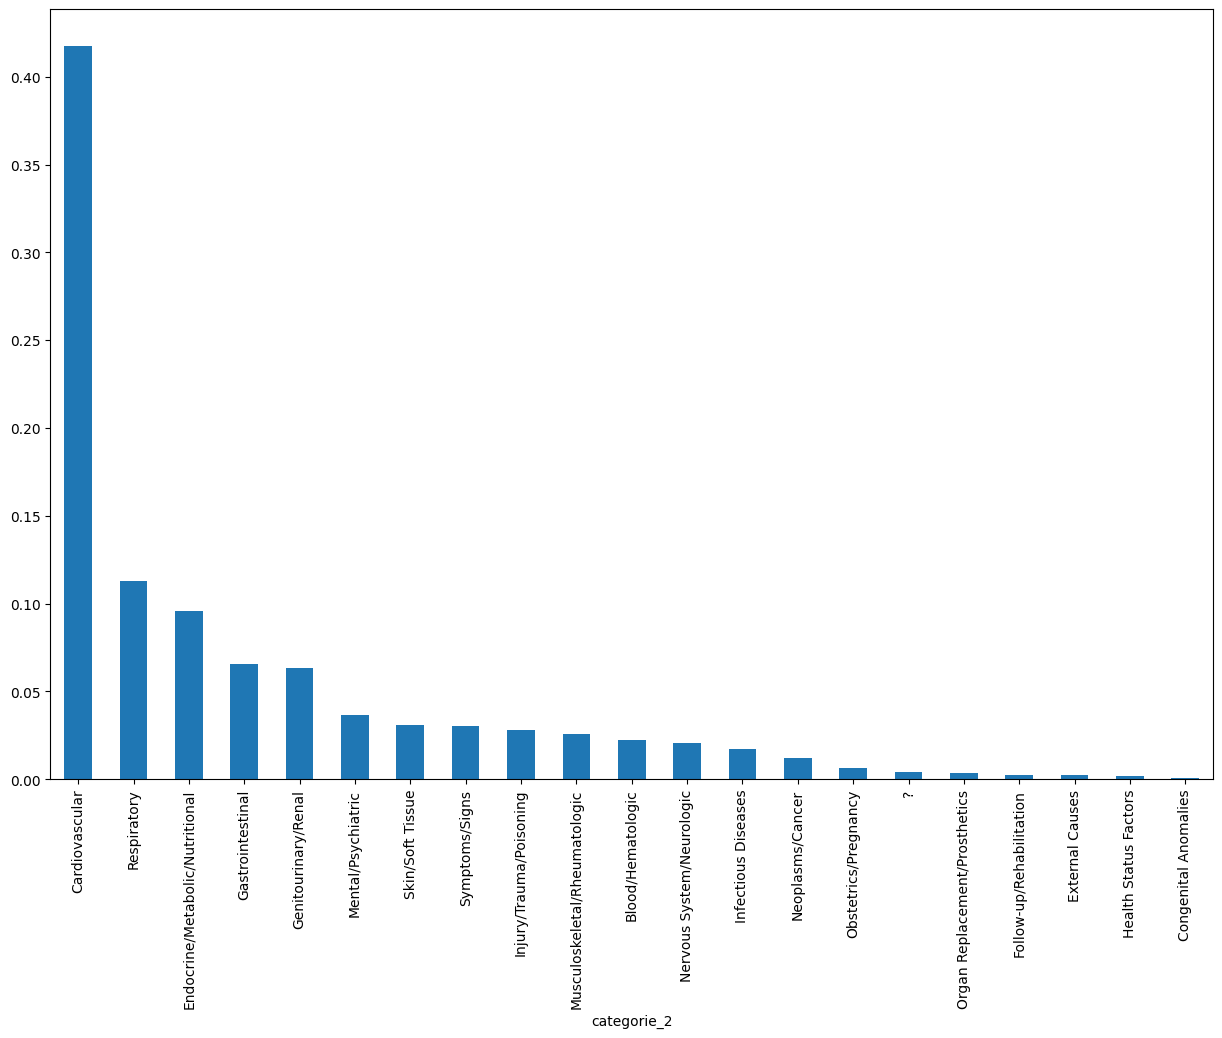

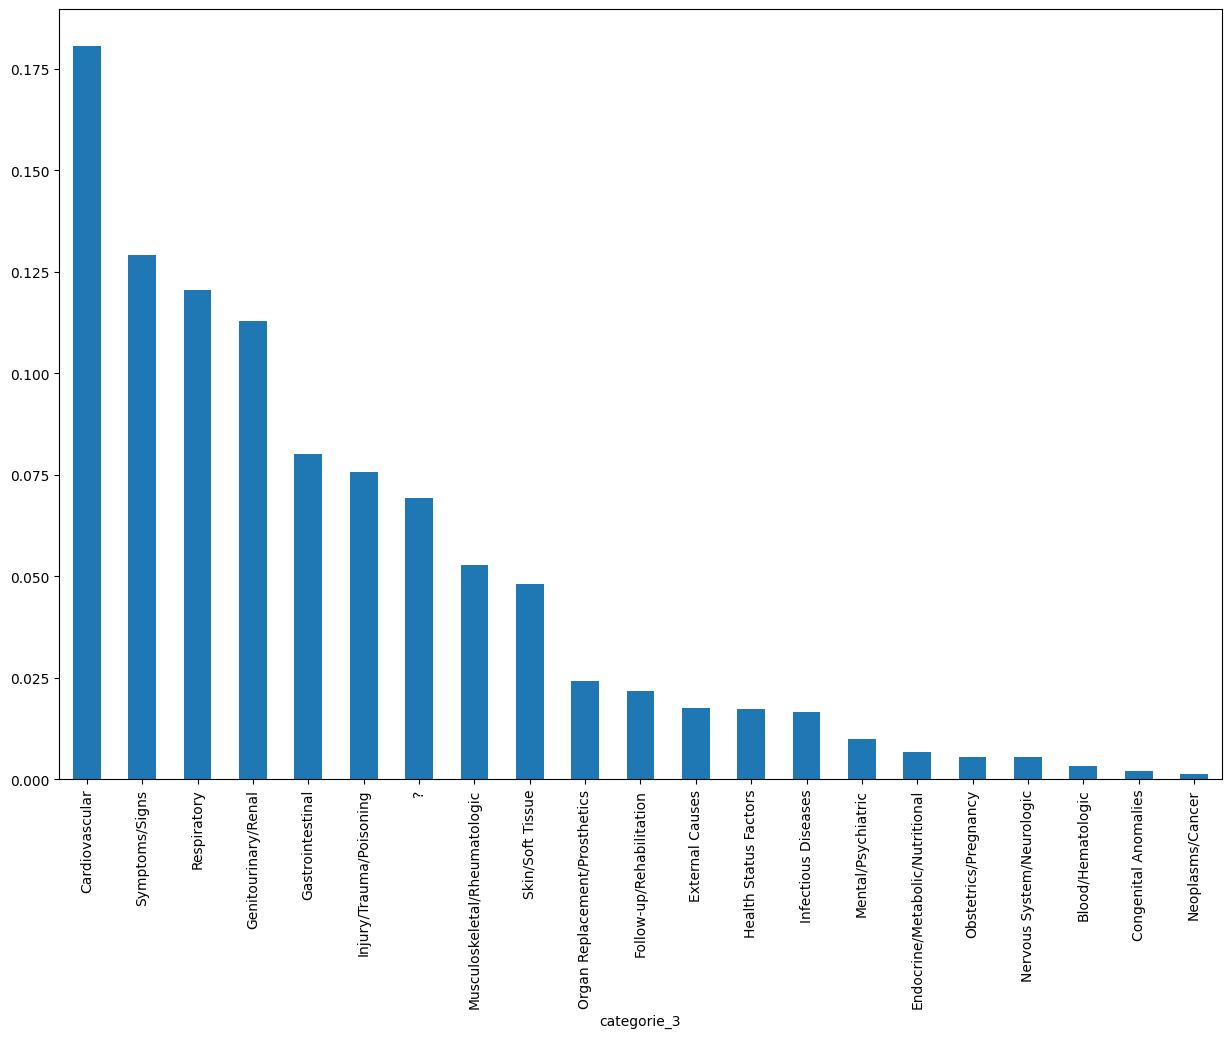

In [ ]:
for col in cols_cat:
    df[col].value_counts(sort=col!="tranche_age", normalize=True)[:50].plot.bar(figsize=(15, 10), legend=False)
    plt.show()

Nous avons une très grande majorité de Caucasiens (~75%), les prédictions seront difficiles pour les autres éthnies.

L'équilibre Homme-Femme (55-45%) est plutôt bien respecté.

Etonnement, 50% des patients ne reçoivent pas d'insuline durant leur séjour.

La distribution des tranches d'age est intéressante, on voit que nos données se concentrent autour des 40-90 ans, les prédictions seront difficiles à l'extérieur de cette tranche d'âge.

Observons les corrélations avec la variable prédictive :

/tmp/ipykernel_2229/159146022.py:14: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



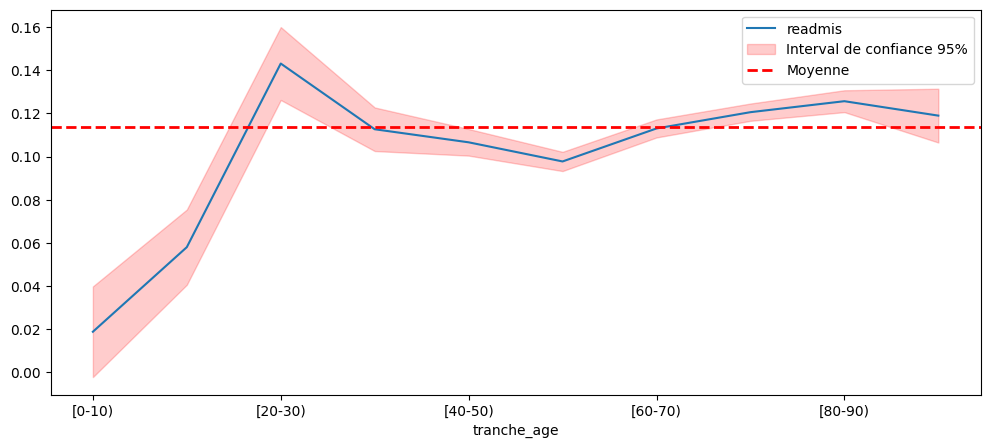

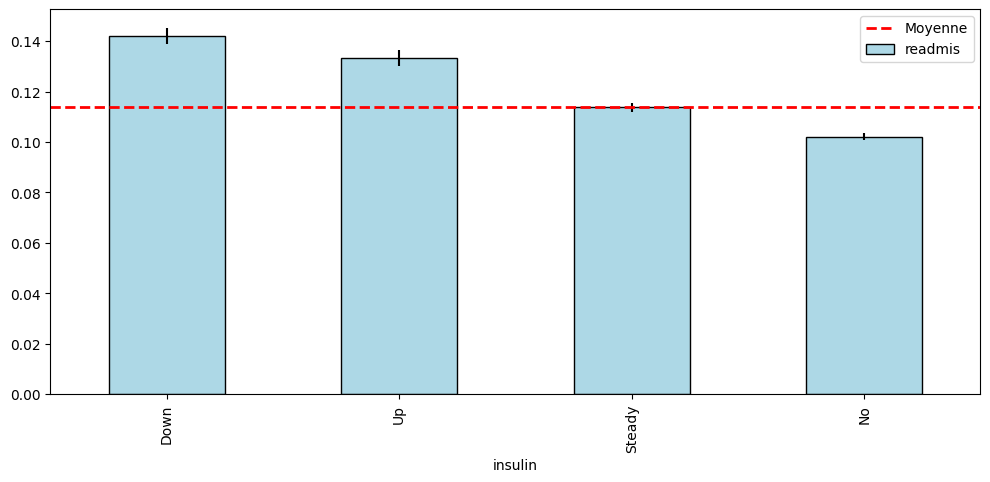

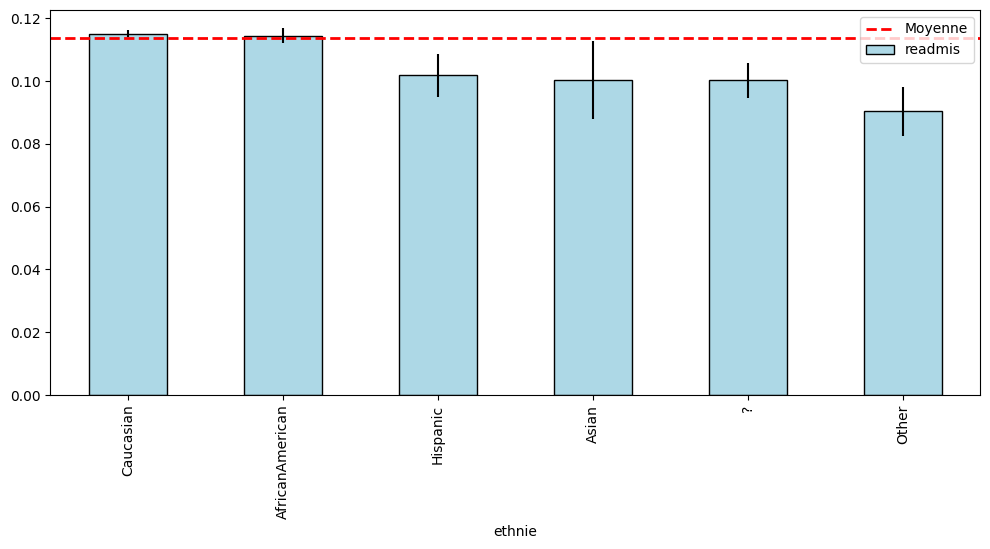

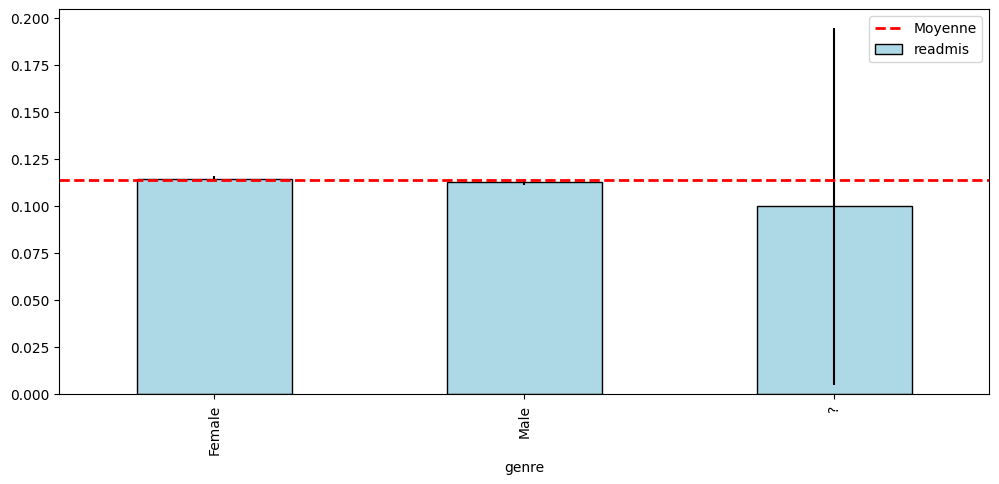

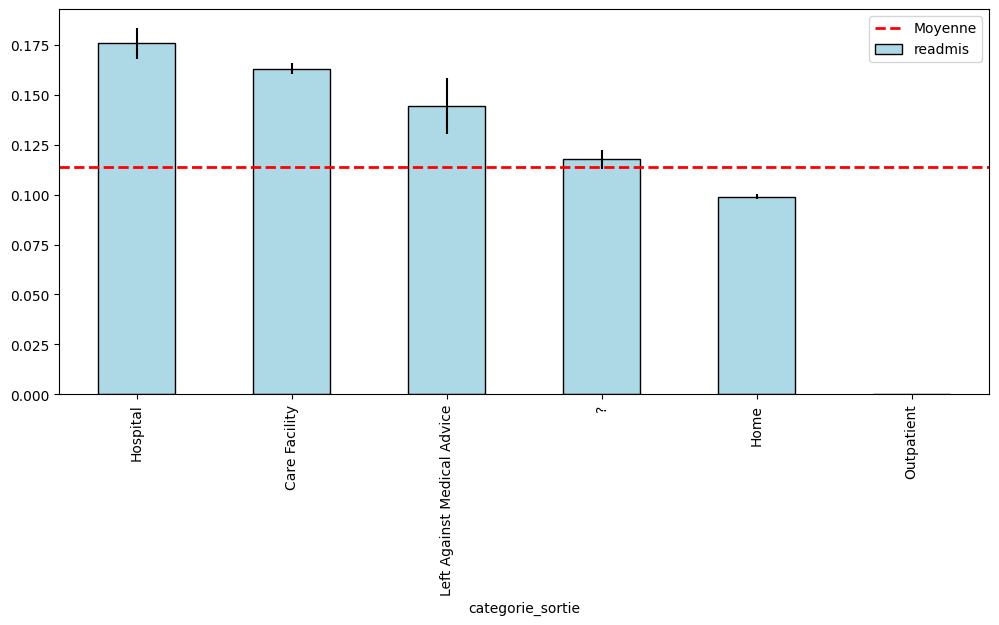

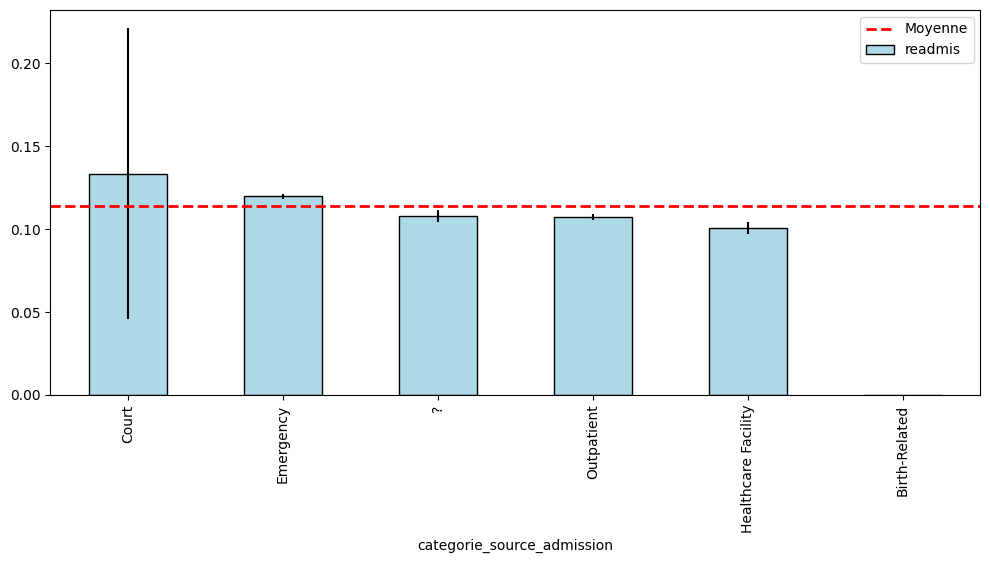

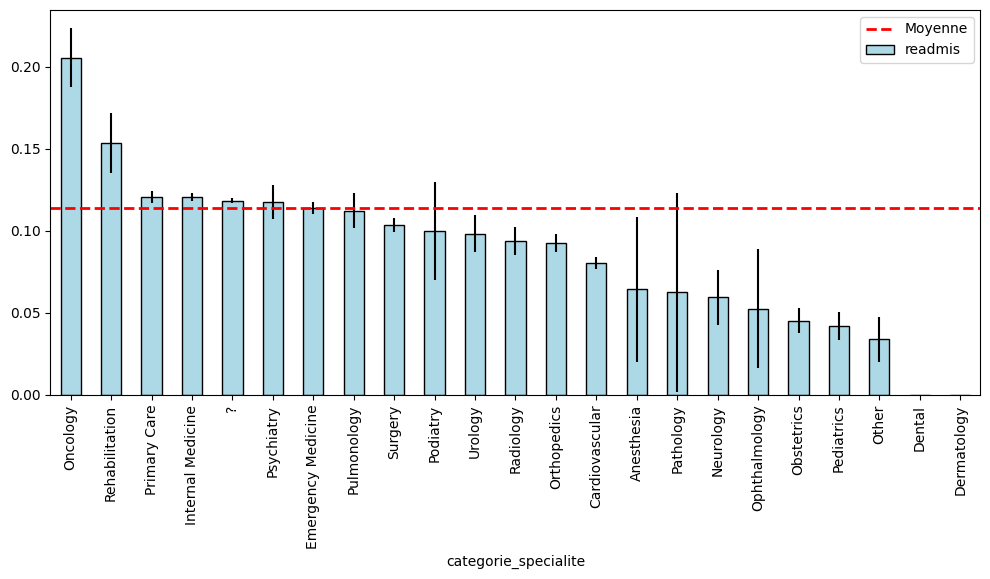

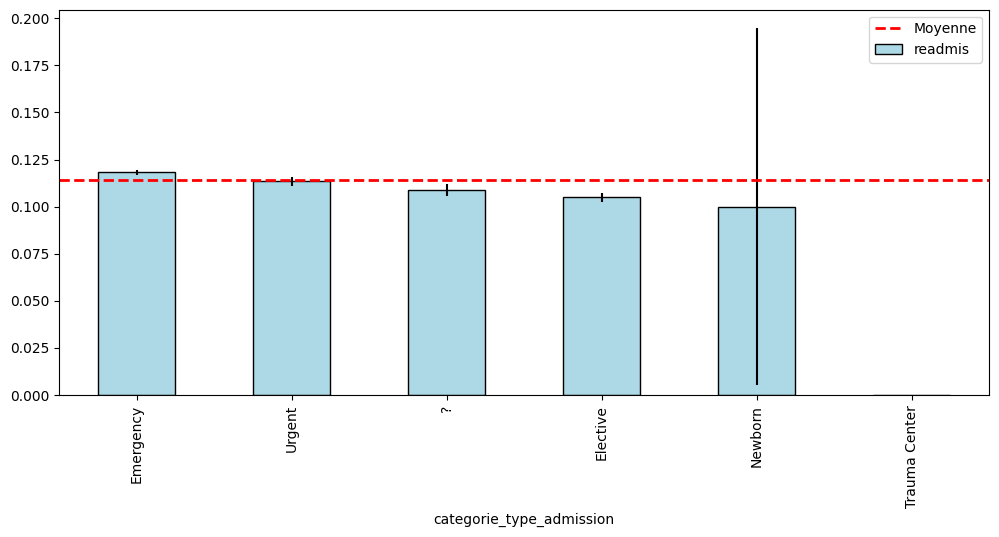

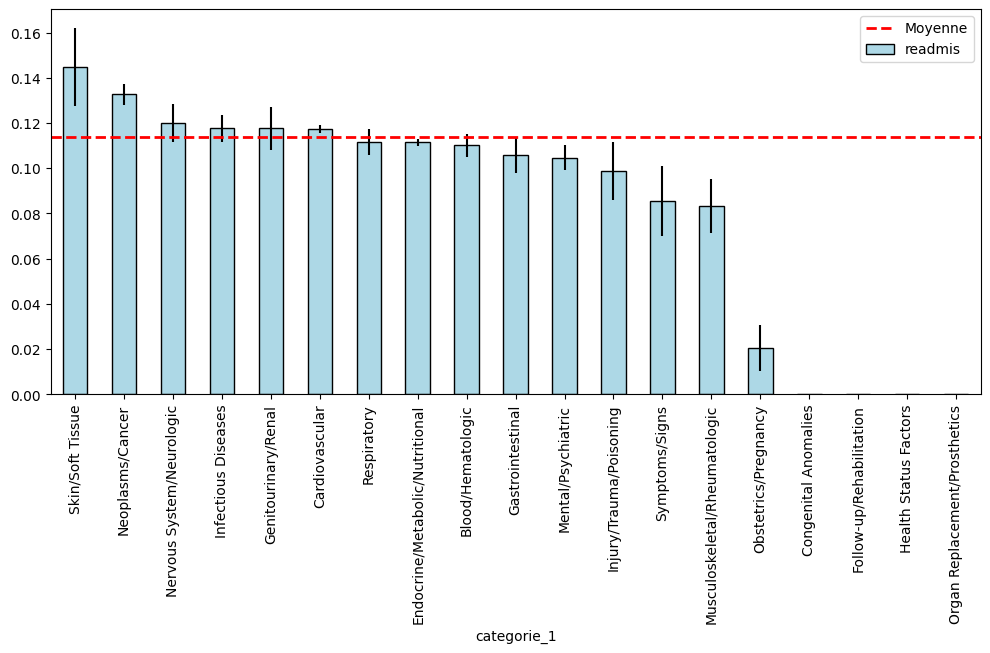

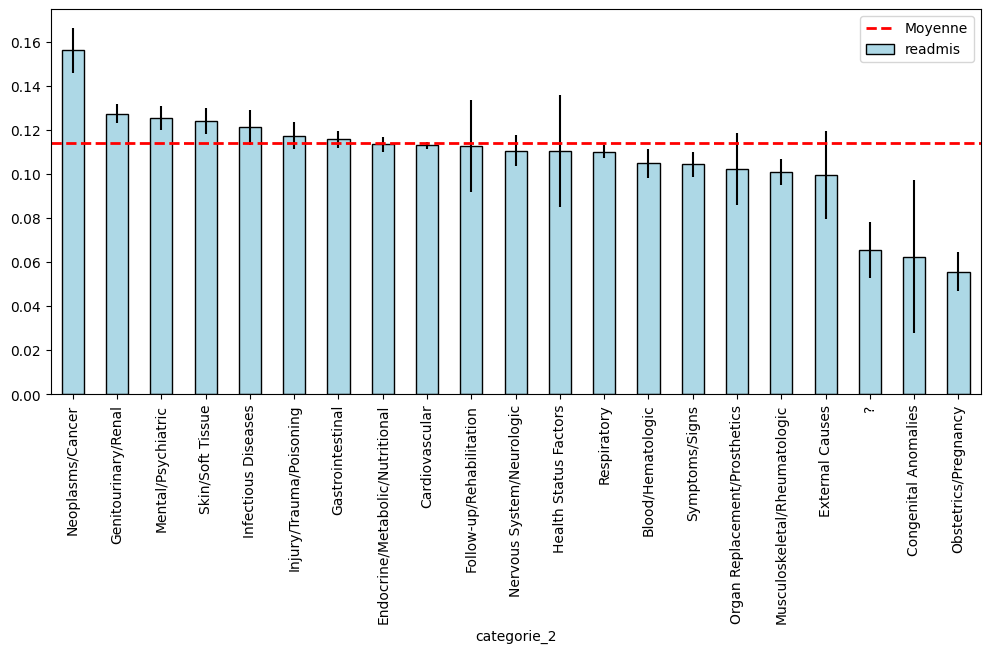

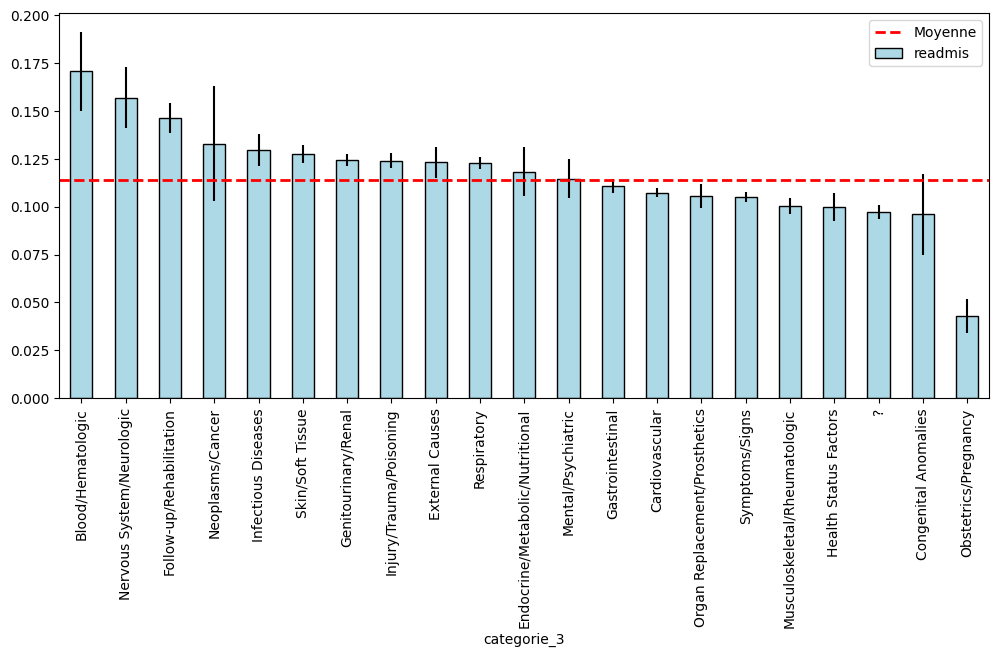

In [ ]:
for col_feature in cols_cat:
    plot_crosstab(df, col_feature)

Un changement de posologie de l'insuline semble associé à une probabilité de réadmission plus élevée.

Le type de sortie pourrait aussi être corrélé avec la réadmission.

Les catégories semblent assez peu liées à la réadmission, notamment l'ethnie et le genre.

### Synthèse de l'exploration

Quelques étrangetées ont été mises en évidence :
- Le nombre exagerement élevé de medicaments préscrits ou de tests en laboratoire éffectués durant la visite
  - Nous avons imposé des limites à 50 et 100 respectivement
- Le nombre de visite médicale (externe, urgence, hopital) 1 an avant l'hospitalisation est 0 dans la quasi-totalité des cas mais peut être éxagérement élevé
  - ->Nous avons calculé un score compris entre 0 et 10 pour modeliser ces visites, donnant un poids important au nombre de visites à l'hôpital car fortement corrélé avec la réadmission.
- Le nombre de diagnostiques effectués durant la visite, avec un pic à 9 et presque aucune valeur supérieure à 9, ce qui est vraissemblablement lié à une limitation humaine/informatique
  - ->Nous avons imposé une limite à 9

La plupart des features, principalement catégorielles, ne semblent pas ou peu corrélées avec la réadmission. Les corrélations numériques observées sont toutes positives.

Le score de visites antérieures est le meilleur prédicteur individuel. Un patient avec plusieurs visites médicales l'année précédente est clairement « consommateur de soins » et plus *fragile*.

Le changement de posologie signale des ajustements difficiles ou des complications pendant le séjour.

Il risque d'être difficile pour un modèle de prédire la réadmission à partir de ces features.